# Klasifikasi Sentimen Publik terhadap Polemik KPAI vs PB Djarum pada Komentar Berita Online

### Proyek UTS Pemrosesan Bahasa Alami — Dataset Development, Anotasi Multilabel & NER

| | |
|---|---|
| **Mata kuliah** | Pemrosesan Bahasa Alami (INFT41603) — Gasal 2026/2027 |
| **Kelompok** | NLP |
| **Anggota (NIM)** | 240712822 · 240712828 · 240712846 |
| **Dataset sumber** | *Abusive Language Detection on Indonesian Online News Comments* (`id_abusive_news_comment`, dataset No. 7 daftar resmi) |
| **Notebook** | `KelpNLP_dataset_EDA.ipynb` — cleaning + EDA (output wajib #5) |

## Deskripsi Proyek

### Latar belakang
Pada 2019, **Komisi Perlindungan Anak Indonesia (KPAI)** menilai *Audisi Umum Beasiswa Bulu Tangkis* yang diselenggarakan **PB Djarum** sebagai bentuk eksploitasi anak, karena peserta anak-anak mengenakan logo merek yang identik dengan produk rokok. Akibatnya, PB Djarum menghentikan audisi tersebut. Polemik ini memicu ribuan komentar pembaca di portal berita: ada yang membela KPAI, ada yang membela PB Djarum, dan banyak yang memakai bahasa kasar.

Dataset asli hanya menandai apakah sebuah komentar **abusif atau tidak**. Label itu tidak bisa menjawab pertanyaan yang lebih penting: **bagaimana sikap publik terhadap masing-masing pihak?**

### Tujuan
Proyek ini mengembangkan dataset tersebut menjadi **gold dataset** untuk dua tugas NLP yang saling terhubung, dengan fokus pada **satu domain spesifik**: polemik **KPAI vs PB Djarum**.

| Tugas | Pertanyaan yang dijawab | Label / entitas |
|---|---|---|
| **A. Multilabel Text Classification** (level teks) | Bagaimana sikap komentar terhadap KPAI dan PB Djarum (positif/negatif), dan apakah bahasanya abusif? | `KPAI_POSITIVE`, `KPAI_NEGATIVE`, `PBDJARUM_POSITIVE`, `PBDJARUM_NEGATIVE`, `ABUSIVE`, `NEUTRAL` |
| **B. Named Entity Recognition** (level kata) | Entitas apa yang dibicarakan? | `GOV_ORG` (lembaga negara), `NONGOV_ORG` (organisasi non-pemerintah), `PERSON`, `GROUP` (kelompok orang) |

Kedua tugas saling terhubung. NER mengenali **siapa** yang dibicarakan, sedangkan multilabel menentukan **sikap** terhadapnya:

```
Teks  : PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet sama pelatih juga..
        sayang kemampuan otaknya orang2 KPAI terbatas..
NER   : [PB Djarum]NONGOV_ORG ... [atlet]GROUP ... [KPAI]GOV_ORG
Label : [PBDJARUM_POSITIVE, KPAI_NEGATIVE, ABUSIVE]
```

### Alur proyek
```
Dataset terpilih → Domain analysis (§4.2) → Cleaning & seleksi domain → Sampling 1.000 teks
→ Taxonomy multilabel + NER → Annotation guideline → Anotasi (Label Studio)
→ Inter-annotator agreement + adjudication → GOLD DATASET (UTS) → EDA → Streamlit dataset explorer
→ (UAS) model multilabel + NER → evaluasi → deployment
```

Notebook ini disusun mengikuti urutan spesifikasi proyek. Bagian pertama adalah **§4.2 Dataset Selection dan Domain Analysis**.

## 0. Setup

Semua path **relatif** terhadap folder proyek `UTS_NLP/`, sehingga notebook bisa dijalankan di komputer mana pun. Jalankan dari folder `notebook/` dengan *Kernel → Restart & Run All*.

In [1]:
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 150)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR = "#3b6ea8"          # satu warna untuk semua grafik jumlah
SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()   # .../UTS_NLP
REPO_DIR = ROOT / "dataset" / "Indonesian-Online-News-Comments"
RAW_PATH = REPO_DIR / "Dataset" / "Abusive Language Detection on Indonesian Online News Comments Dataset .xlsx"
README_PATH = REPO_DIR / "README.md"

print("ROOT     :", ROOT)
print("Dataset  :", RAW_PATH.relative_to(ROOT), "| ada:", RAW_PATH.exists())

ROOT     : /home/claude/UTS_NLP
Dataset  : dataset/Indonesian-Online-News-Comments/Dataset/Abusive Language Detection on Indonesian Online News Comments Dataset .xlsx | ada: True


---
# 4.2 Dataset Selection dan Domain Analysis

Bagian ini memahami dataset sebagai **data nyata**, bukan sekadar file yang akan diproses. Sesuai spesifikasi 4.2, ada tujuh hal yang dibahas:

| No | Poin spesifikasi | Subbagian |
|---|---|---|
| 1 | Sumber dan tujuan awal dataset | 4.2.1 |
| 2 | Bahasa serta domain data | 4.2.2 |
| 3 | Jumlah data dan struktur kolom | 4.2.3 |
| 4 | Label asli | 4.2.4 |
| 5 | Distribusi awal data | 4.2.5 |
| 6 | Masalah kualitas data | 4.2.6 |
| 7 | Potensi pengembangan menjadi multilabel dan NER | 4.2.7 |

Ringkasannya ada di **4.2.8**.

## 4.2.1 Sumber dan tujuan awal dataset

| Aspek | Keterangan |
|---|---|
| Nama | *Abusive Language Detection on Indonesian Online News Comments* |
| Asal | Repository GitHub penulis paper (folder `dataset/Indonesian-Online-News-Comments/`) |
| Publikasi | Paper IEEE Xplore doc. **9034620** |
| Sumber teks | Kolom komentar pembaca **Kompas**, **Kaskus**, dan **Detik** pada **15 berita populer tahun 2019** |
| Cara pengumpulan | *Crawling* komentar per berita (notebook `Code/0. Crawling Dataset.ipynb` memakai API komentar Detik) |
| Pelabelan asli | Dilakukan oleh beberapa annotator; setiap komentar diberi **1 dari 3 label** tingkat keabusifan |
| **Tujuan awal** | **Mendeteksi bahasa abusif** (*abusive language detection*) sebagai tugas klasifikasi 3 kelas. Penulis membandingkan Naive Bayes, SVM, dan KNN dengan seleksi fitur *Mutual Information*; SVM terbaik dengan akurasi 90,19% |
| Lisensi | Repo tidak menyertakan file LICENSE → dipakai untuk keperluan akademik dan **wajib disitasi** |

Daftar 15 berita sumber dibaca langsung dari README repo:

In [2]:
readme = README_PATH.read_text(encoding="utf-8")
headlines = [l.strip("- ").strip() for l in readme.splitlines() if l.startswith("- ") and "'" not in l[:3]]
headlines = [h for h in headlines if not h.lower().startswith(("1 '", "2 '", "3 '"))]
pd.DataFrame({"no": range(1, len(headlines) + 1), "judul berita sumber (2019)": headlines}).set_index("no")

,judul berita sumber (2019)
no,
1,"Sandi Butuh Rp 9,9 T untuk 'Rebut' Indosat dari Investor Qatar"
2,"Fadli Zon Dicurhati Tol Mahal, Ini Tarif Trans Jawa & Sumatera"
3,"Menuai Protes, Pemprov DKI Batalkan Kegiatan yang Undang Muslimah HTI"
4,KPU Sindir Kubu Prabowo: TIM IT Mereka Terlalu Pintar
5,"Kasus Ujaran Idiot, Ahmad Dhani Divonis 1 Tahun Penjara"
6,"Demokrat: SBY Minta Prabowo Sebut Kebaikan Ani, Bukan soal Politik"
7,"Penyesalan Luna Maya Posting Cuplikan Film Aladdin, Ini Jadi Pelajaran"
8,Masih Ingat Operator Esia? Begini Nasibnya Sekarang
9,"Jika Revisi UU KPK Disahkan, UII Siap Ajukan Mosi Tak Percaya ke Jokowi"


**Catatan:** dari 15 berita, **3 berita** membahas langsung polemik KPAI vs PB Djarum: no. 10 ("Orang Tua Anak Peserta Audisi PB Djarum: KPAI Survei Ke Anak Yang Mana??"), no. 12 ("#bubarkanKPAI Trending di Twitter, KPAI Angkat Bicara"), dan no. 15 ("PB Djarum Hentikan Audisi Bulutangkis, Ini Kata KPAI"). Berita no. 11 (SpongeBob di GTV, tentang sensor KPI) letaknya berdekatan di dataset. Tiga berita inilah yang membuat polemik KPAI vs PB Djarum menjadi topik terbesar di dataset (dibuktikan di 4.2.2).

## 4.2.2 Bahasa serta domain data

Sebelum membahas bahasa dan domain, data dimuat terlebih dahulu. Setiap baris diberi ID permanen `ANC-0001` … sesuai urutan baris asli, supaya setiap perubahan di tahap berikutnya bisa dilacak kembali.

In [3]:
raw = pd.read_excel(RAW_PATH)
raw.insert(0, "id", [f"ANC-{i + 1:04d}" for i in range(len(raw))])
raw["Kalimat"] = raw["Kalimat"].astype(str)
raw.head(8)

,id,Kalimat,label
0,ANC-0001,san ente aje yg unboxing Indosat. masa ente kalah ama kemenakan Prabowo...unboxing mesin atm wkwkwkwkwk,1
1,ANC-0002,"‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g ada jaringannya, mentok2 cuma 2G, harusnya pikir paka...",3
2,ANC-0003,Ngotot mau beli saham indosat kok jika jd presiden??? Ada apa ya??. Jika menguntungkan knp Sandi yg pengusaha & uangnya banyak tdk beli indosat bu...,1
3,ANC-0004,"Buyback Isat??anda sehat??sdh diminum obatnya??... Sinyal lelet,paket data omdo,hutang msh trilyunan..coba kau pikirkan kembali Adolfo??!!",1
4,ANC-0005,"Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,ÔøΩ",1
5,ANC-0006,"HaHaHa... Lucu! Dengan harga jauh di atas Rp. 9,9 Triliun sajs Ooredoo Qatar belum tentu mau. Nilai Indosat terlalu rendah saat ini. Per Desember ...",1
6,ANC-0007,Yg jual Indosat siapa ...??? Yg mau beli balik siapa...????ÔøΩ,1
7,ANC-0008,"Ngapain beli indosat?? Sinyal lelet gaje, wkwkwk",1


### a. Bahasa
Komentar ditulis dalam **Bahasa Indonesia informal (bahasa media sosial)**. Cirinya bisa dihitung langsung dari data: singkatan, kata tidak baku, bahasa daerah/Betawi, slang internet, dan campuran bahasa Inggris.

In [4]:
t_low = raw["Kalimat"].str.lower()
ciri_bahasa = {
    "singkatan (yg, gk, klo, tdk, dgn, sdh, jd)": r"\b(yg|gk|klo|kalo|tdk|dgn|sdh|udh|jd|krn|blm|bgt)\b",
    "kata tidak baku (gak, nggak, aja, udah, emang)": r"\b(gak|ga|nggak|ngga|aja|udah|emang|kayak|gimana)\b",
    "Betawi/daerah (ente, ane, lu, gue, gw)": r"\b(ente|ane|lu|loe|gue|gw|elu)\b",
    "slang internet (wkwk, gan, bro, sis)": r"wkwk|\b(gan|bro|sis|bray)\b|haha",
    "bahasa Inggris (the, and, is, you)": r"\b(the|and|is|you|this|what)\b",
    "reduplikasi dengan angka (anak2, orang2)": r"\b[a-z]{2,}2\b",
}
tbl = pd.DataFrame({"jumlah komentar": {k: int(t_low.str.contains(p).sum()) for k, p in ciri_bahasa.items()}})
tbl["persen"] = (tbl["jumlah komentar"] / len(raw) * 100).round(1)
tbl

,jumlah komentar,persen
"singkatan (yg, gk, klo, tdk, dgn, sdh, jd)",1139,35.8
"kata tidak baku (gak, nggak, aja, udah, emang)",1081,34.0
"Betawi/daerah (ente, ane, lu, gue, gw)",250,7.9
"slang internet (wkwk, gan, bro, sis)",187,5.9
"bahasa Inggris (the, and, is, you)",34,1.1
"reduplikasi dengan angka (anak2, orang2)",565,17.7


In [5]:
kata = Counter(w for s in t_low for w in re.findall(r"[a-z]+", s))
print("Ukuran kosakata (kata unik):", len(kata))
print("20 kata tersering:", [w for w, _ in kata.most_common(20)])

Ukuran kosakata (kata unik): 9259
20 kata tersering: ['yg', 'kpai', 'anak', 'di', 'dan', 'yang', 'ada', 'ini', 'djarum', 'itu', 'aja', 'ga', 'dari', 'ya', 'apa', 'bisa', 'tidak', 'gak', 'juga', 'nya']


**Interpretasi:** bentuk informal sangat dominan. Kata tersering justru `yg` (bukan `yang`), dan `kpai` masuk 2 besar. Konsekuensinya, tahap normalisasi (kamus singkatan) perlu dilakukan untuk analisis kosakata, tetapi **teks asli tetap dipakai untuk anotasi** agar informasi seperti huruf kapital, emoji, dan makian tidak hilang.

### b. Domain
Domain umum dataset adalah **opini publik pada komentar berita politik, kebijakan, dan sosial di Indonesia tahun 2019**. Untuk menentukan domain spesifik proyek, topik setiap komentar diidentifikasi dengan dua cara:

1. **Kata kunci**: mencocokkan kata khas dari ke-15 berita (mis. `kpai`, `djarum`, `audisi` → KPAI vs PB Djarum).
2. **Posisi baris**: dataset tersusun **berurutan per berita**, sehingga komentar tanpa kata kunci (mis. `Bubarkan saja!!`) diberi topik mayoritas dari ±12 baris di sekitarnya.

In [6]:
TOPIC_KEYWORDS = {
    "KPAI vs PB Djarum": r"kpai|djarum|\bjarum\b|audisi|bulu ?tangkis|\bkpi\b",
    "Revisi UU KPK": r"\bkpk\b|revisi|penyadapan|dewan pengawas|korupsi",
    "Indosat / Sandi": r"indosat|\bisat\b|sandi|ooredoo|qatar",
    "Tarif tol / Fadli Zon": r"\btol\b|fadli",
    "HTI / Pemprov DKI": r"\bhti\b|muslimah|pemprov|anies",
    "SpongeBob / GTV": r"spongebob|patrick|\bgtv\b|squarepants|kartun",
    "Esia": r"\besia\b|bakrie",
    "Luna Maya": r"luna|aladdin",
    "KPU / Tim IT": r"\bkpu\b|tim it",
    "SBY / Ani": r"\bsby\b|bu ani|\bani\b",
    "Ahmad Dhani": r"dhani",
}

def assign_topic(text: str) -> str:
    """Topik berdasarkan kata kunci 15 berita sumber."""
    t = text.lower()
    for topic, pattern in TOPIC_KEYWORDS.items():
        if re.search(pattern, t):
            return topic
    return "tidak terdeteksi"

def assign_segment(df: pd.DataFrame, window: int = 12) -> pd.Series:
    """Topik berita asal dari POSISI baris: mayoritas topik kata kunci di ±window baris."""
    kw = df["topic_keyword"].where(df["topic_keyword"] != "tidak terdeteksi").reset_index(drop=True)
    out = []
    for i in range(len(kw)):
        w = kw.iloc[max(0, i - window): i + window + 1].dropna()
        out.append(w.mode().iloc[0] if len(w) else "tidak terdeteksi")
    return pd.Series(out, index=df.index)

raw["topic_keyword"] = raw["Kalimat"].map(assign_topic)
raw["segment"] = assign_segment(raw)

topik = pd.DataFrame({
    "kata kunci": raw["topic_keyword"].value_counts(),
    "posisi baris": raw["segment"].value_counts(),
}).fillna(0).astype(int).sort_values("posisi baris", ascending=False)
topik["≥ 800 teks?"] = np.where(topik["posisi baris"] >= 800, "✅", "—")
topik

,kata kunci,posisi baris,≥ 800 teks?
KPAI vs PB Djarum,1246,1836,✅
Revisi UU KPK,156,323,—
Tarif tol / Fadli Zon,97,295,—
Indosat / Sandi,104,192,—
HTI / Pemprov DKI,64,158,—
Esia,46,133,—
Luna Maya,12,82,—
KPU / Tim IT,9,62,—
tidak terdeteksi,1399,55,—
SBY / Ani,6,33,—


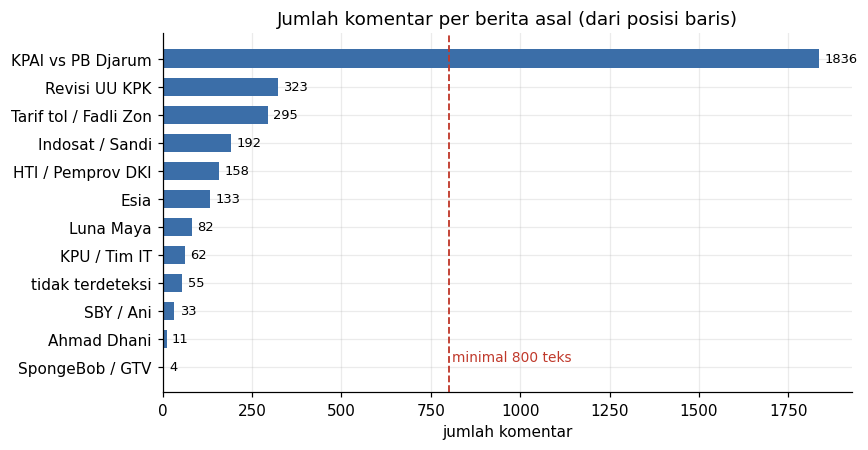

In [7]:
seg = raw["segment"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(seg.index, seg.values, color=BAR, height=0.65)
ax.axvline(800, color="#c0392b", ls="--", lw=1.2)
ax.text(810, 0.2, "minimal 800 teks", color="#c0392b", fontsize=9)
for i, v in enumerate(seg.values):
    ax.text(v + 15, i, str(v), va="center", fontsize=8.5)
ax.set_title("Jumlah komentar per berita asal (dari posisi baris)")
ax.set_xlabel("jumlah komentar")
plt.tight_layout(); plt.show()

In [8]:
# rentang baris berita KPAI vs PB Djarum
raw["_blok"] = (raw["segment"] != raw["segment"].shift()).cumsum()
blok = (raw[raw["segment"] == "KPAI vs PB Djarum"].groupby("_blok")
        .agg(dari=("id", "first"), sampai=("id", "last"), jumlah=("id", "size")))
display(blok[blok["jumlah"] >= 20].reset_index(drop=True))
raw = raw.drop(columns="_blok")

,dari,sampai,jumlah
0,ANC-1119,ANC-1461,343
1,ANC-1466,ANC-2008,543
2,ANC-2235,ANC-3184,950


**Interpretasi:**
- Metode kata kunci saja meninggalkan banyak komentar **tidak terdeteksi**, karena orang sering berkomentar tanpa menyebut topik. Metode posisi baris berhasil memberi topik pada hampir semua komentar.
- **KPAI vs PB Djarum adalah satu-satunya topik dengan lebih dari 800 komentar.** Topik terbesar berikutnya (Revisi UU KPK) hanya ±320 komentar. Ini menjadi dasar kuat pemilihan domain, sesuai arahan dosen untuk memilih satu domain spesifik.
- Komentar KPAI vs PB Djarum berada di **3 rentang baris** (utas). Di dalam rentang itu terselip komentar tentang **KPI/sensor SpongeBob** (berita no. 11), yang akan dibuang saat seleksi domain di tahap cleaning (4.3).

**Domain proyek:** polemik **KPAI vs PB Djarum** — komentar publik tentang penghentian audisi bulu tangkis karena isu eksploitasi anak dan branding rokok.

## 4.2.3 Jumlah data dan struktur kolom

In [9]:
asli = pd.read_excel(RAW_PATH)
print(f"Jumlah baris : {asli.shape[0]:,}")
print(f"Jumlah kolom : {asli.shape[1]}")
struktur = pd.DataFrame({
    "tipe data": asli.dtypes.astype(str),
    "jumlah non-null": asli.notna().sum(),
    "missing": asli.isna().sum(),
    "nilai unik": asli.nunique(),
    "contoh nilai": [asli[c].iloc[1] for c in asli.columns],
})
struktur

Jumlah baris : 3,184
Jumlah kolom : 2


,tipe data,jumlah non-null,missing,nilai unik,contoh nilai
Kalimat,object,3184,0,3169,"‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g ada jaringannya, mentok2 cuma 2G, harusnya pikir paka..."
label,int64,3184,0,3,3


| Kolom | Isi | Keterangan |
|---|---|---|
| `Kalimat` | teks komentar (string) | Satu baris = satu komentar. Bisa lebih dari satu kalimat, termasuk baris baru, emoji, dan hashtag |
| `label` | bilangan bulat 1, 2, atau 3 | Label tingkat keabusifan (lihat 4.2.4) |

**Yang tidak tersedia:** ID komentar, nama/ID akun, tanggal, sumber portal per baris, dan judul berita. Karena itu notebook menambahkan `id` sendiri, dan topik ditentukan dari posisi baris (4.2.2).

## 4.2.4 Label asli

Dataset memiliki **satu label per komentar** (*single-label*, 3 kelas). Definisi diambil dari README repo:

| Label | Nama | Arti |
|---|---|---|
| **1** | *not abusive* | komentar tidak mengandung bahasa abusif |
| **2** | *abusive but not offensive* | mengandung kata abusif/kasar tetapi tidak menyerang (mis. candaan) |
| **3** | *abusive and offensive* | mengandung bahasa abusif **dan** menyerang/menghina pihak tertentu |

Contoh acak untuk setiap label:

In [10]:
LABEL_NAMA = {1: "not abusive", 2: "abusive but not offensive", 3: "abusive and offensive"}
for lab, nama in LABEL_NAMA.items():
    display(Markdown(f"**Label {lab} — {nama}**"))
    contoh = raw.loc[(raw["label"] == lab) & (raw["Kalimat"].str.len() < 160), ["id", "Kalimat"]]
    display(contoh.sample(4, random_state=SEED))

**Label 1 — not abusive**

,id,Kalimat
2093,ANC-2094,"Klo menyadap prlu izin...bkn menyadap tuh, namanya mendengarkan dgn seksama.. Keburu bocor lah...aneh tu DPR"
3066,ANC-3067,Mudah2an KPAI yang akan meneruskan audisi bulutangkis untuk anak-anak sehingga mendapatkan bibit bibit yang berbakat.
891,ANC-0892,"Paling bt pas yg didepan menyalakan hp, apalagi ternyata merekam adegan biar sebentar tapi mengganggu \n\nTapi semoga LM tidak sampai ditahan, kas..."
37,ANC-0038,"Wakakak.... Akan diusahakan, tukang sayur juga bisa bilang begitu"


**Label 2 — abusive but not offensive**

,id,Kalimat
844,ANC-0845,terus g di proses hukum ?!\n\nnajis dah
119,ANC-0120,Mundur kotanya.. Gila warganya..
799,ANC-0800,"Bukan kebodohan itu mah, kenikmatan"
850,ANC-0851,"""Itu kebodohan aku aja. Jangan sampe diulangi lagi pelajarannya,"" ungkapnya.\n\n\n\n\n\n\n\n""bikin film"" sama A, kebodohan bukan?"


**Label 3 — abusive and offensive**

,id,Kalimat
1331,ANC-1332,"toket yang ada di pantung, gambar, lukisan.\nsemuanya harus kena blur, itu udah peraturan yanng di terapkan QC"
265,ANC-0266,mulut rusak.......keluarnya omongan benci terus....
364,ANC-0365,"Curhat kok ke mulut ember harusnya ke pemerintah atuh... beli mobilnya kuat kok bayar tol nya ga kuat, jual aja mobilnya bro..."
2391,ANC-2392,"KPAI ini ga ada kerjaan, apa emang isinya orang TOLOL semua sih #BubarkanKPAI"


**Catatan:** label asli hanya mengukur **tingkat keabusifan**. Label ini tidak memuat informasi **sentimen** (setuju/menolak), **target** (KPAI atau PB Djarum), maupun **entitas** yang dibicarakan. Itu sebabnya label asli hanya dipakai sebagai **referensi awal** (misalnya untuk sampling dan perbandingan), bukan sebagai skema proyek.

## 4.2.5 Distribusi awal data

### a. Distribusi label asli — seluruh dataset vs domain KPAI vs PB Djarum

In [11]:
def dist_label(df):
    vc = df["label"].value_counts().sort_index()
    return pd.DataFrame({"jumlah": vc, "persen": (vc / vc.sum() * 100).round(2)})

domain = raw[raw["segment"] == "KPAI vs PB Djarum"]
dist = pd.concat({"seluruh dataset": dist_label(raw), "domain KPAI vs PB Djarum": dist_label(domain)}, axis=1)
dist.index = [f"{i} — {LABEL_NAMA[i]}" for i in dist.index]
display(dist)
semua = raw["label"].value_counts()
print(f"Imbalance ratio (terbesar : terkecil) seluruh dataset = {semua.max() / semua.min():.1f} : 1")

seluruh dataset        domain KPAI vs PB Djarum  \
                                       jumlah persen                   jumlah   
1 — not abusive                          2789  87.59                     1615   
2 — abusive but not offensive             110   3.45                       51   
3 — abusive and offensive                 285   8.95                      170   

                                      
                              persen  
1 — not abusive                87.96  
2 — abusive but not offensive   2.78  
3 — abusive and offensive       9.26

Imbalance ratio (terbesar : terkecil) seluruh dataset = 25.4 : 1


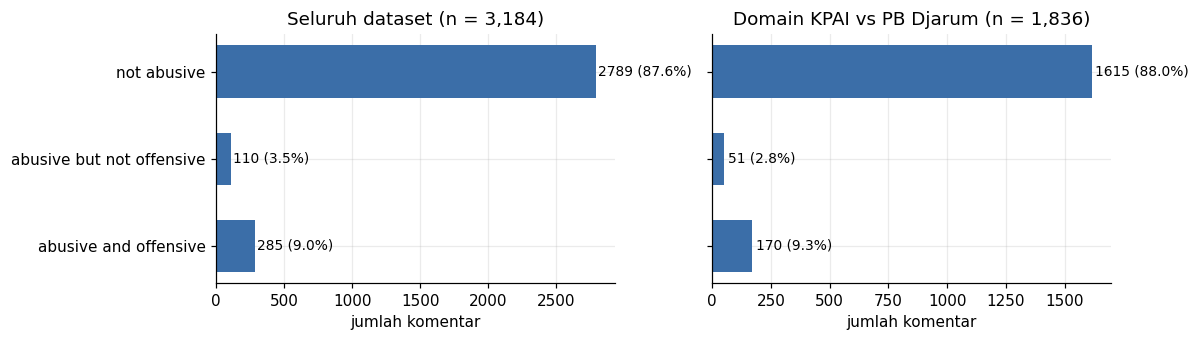

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, (judul, df) in zip(axes, [("Seluruh dataset", raw), ("Domain KPAI vs PB Djarum", domain)]):
    vc = df["label"].value_counts().sort_index()
    ax.barh([LABEL_NAMA[i] for i in vc.index], vc.values, color=BAR, height=0.6)
    for i, v in enumerate(vc.values):
        ax.text(v + 15, i, f"{v} ({v / vc.sum() * 100:.1f}%)", va="center", fontsize=9)
    ax.set_title(f"{judul} (n = {len(df):,})"); ax.set_xlabel("jumlah komentar")
axes[0].invert_yaxis()
plt.tight_layout(); plt.show()

### b. Distribusi panjang teks

In [13]:
raw["n_kata"] = raw["Kalimat"].str.split().str.len()
raw["n_karakter"] = raw["Kalimat"].str.len()
display(raw[["n_kata", "n_karakter"]].describe().round(1).T)
display(raw.groupby("label")["n_kata"].describe().round(1).rename(index=LABEL_NAMA))

,count,mean,std,min,25%,50%,75%,max
n_kata,3184.0,19.9,21.0,1.0,8.0,14.0,26.0,486.0
n_karakter,3184.0,129.1,138.2,2.0,47.0,88.5,164.0,3162.0


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
not abusive,2789.0,19.9,21.3,1.0,8.0,14.0,25.0,486.0
abusive but not offensive,110.0,19.5,19.7,1.0,6.0,14.5,26.0,118.0
abusive and offensive,285.0,20.4,18.7,1.0,7.0,15.0,29.0,110.0


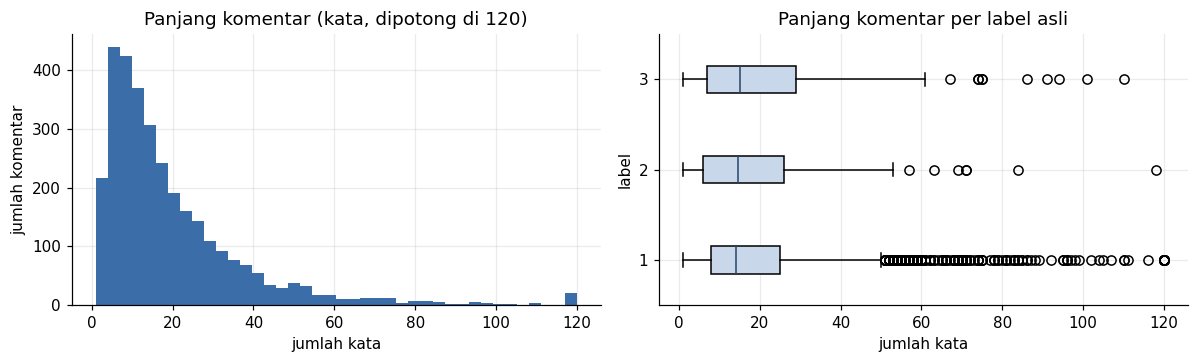

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(raw["n_kata"].clip(upper=120), bins=40, color=BAR)
axes[0].set_title("Panjang komentar (kata, dipotong di 120)"); axes[0].set_xlabel("jumlah kata"); axes[0].set_ylabel("jumlah komentar")
data = [raw.loc[raw["label"] == l, "n_kata"].clip(upper=120) for l in (1, 2, 3)]
axes[1].boxplot(data, labels=["1", "2", "3"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#c9d7ea"), medianprops=dict(color="#24456b"))
axes[1].set_title("Panjang komentar per label asli"); axes[1].set_xlabel("jumlah kata"); axes[1].set_ylabel("label")
plt.tight_layout(); plt.show()

### c. Distribusi label per topik

In [15]:
ct = pd.crosstab(raw["segment"], raw["label"], margins=True, margins_name="total")
ct.columns = [f"label {c}" if c != "total" else c for c in ct.columns]
ct["% abusif (2+3)"] = ((ct["label 2"] + ct["label 3"]) / ct["total"] * 100).round(1)
ct.sort_values("total", ascending=False)

,label 1,label 2,label 3,total,% abusif (2+3)
segment,,,,,
total,2789,110,285,3184,12.4
KPAI vs PB Djarum,1615,51,170,1836,12.0
Revisi UU KPK,301,4,18,323,6.8
Tarif tol / Fadli Zon,243,7,45,295,17.6
Indosat / Sandi,170,7,15,192,11.5
HTI / Pemprov DKI,151,1,6,158,4.4
Esia,124,8,1,133,6.8
Luna Maya,51,16,15,82,37.8
KPU / Tim IT,47,7,8,62,24.2


**Interpretasi:**
- Data **sangat tidak seimbang**: ±88% komentar berlabel *not abusive*, dengan rasio kelas terbesar : terkecil sekitar **25 : 1**. Dampaknya terlihat di notebook asli repo: model mencapai akurasi ±87% hanya dengan **selalu menebak kelas 1** (recall kelas 2 dan 3 = 0). Proyek ini karena itu tidak akan memakai *accuracy* sebagai satu-satunya metrik.
- Panjang komentar sangat bervariasi (median ±14 kata, ada yang ratusan kata), tetapi **hampir sama di ketiga label**. Jadi panjang teks bukan pembeda keabusifan.
- Domain KPAI vs PB Djarum memiliki proporsi abusif yang mirip dengan keseluruhan data (±11–12%), sehingga label `ABUSIVE` tetap minoritas dan perlu diperhatikan saat sampling.

## 4.2.6 Masalah kualitas data yang ditemukan

Pemeriksaan dilakukan pada teks **asli** (sebelum cleaning). Ada lima kelompok masalah: (a) noise teknis, (b) duplikat & teks tidak layak, (c) noise linguistik, (d) masalah label, dan (e) masalah metadata.

### a. Noise teknis (encoding, karakter, markup)

In [16]:
t = raw["Kalimat"].astype(object)   # object dtype: regex Python (mendukung backreference)

def fix_mojibake(s):
    """UTF-8 yang terbaca sebagai Mac Roman -> teks asli. Jika gagal, kembalikan teks semula."""
    try:
        return s.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

def decode_pct(s):
    """'%uD83D%uDE02' -> emoji (escape gaya JavaScript, termasuk surrogate pair)."""
    def rep(m):
        cps = [int(x, 16) for x in re.findall(r"%u([0-9A-Fa-f]{4})", m.group(0))]
        return "".join(map(chr, cps)).encode("utf-16", "surrogatepass").decode("utf-16", "replace")
    return re.sub(r"(?:%u[0-9A-Fa-f]{4})+", rep, s)

pulih = t.map(fix_mojibake).map(decode_pct)        # teks setelah encoding diperbaiki (untuk pengecekan)

def cek(pola, regex=True, seri=None):
    seri = t if seri is None else seri
    m = seri.str.contains(pola, regex=regex)
    contoh = seri[m].iloc[0][:90] if m.any() else ""
    return int(m.sum()), repr(contoh)

noise_teknis = {
    "Mojibake (UTF-8 terbaca sebagai Mac Roman: ÔøΩ, \\uf8ff, ‚Å£)": (int((t.map(fix_mojibake) != t).sum()), repr(t[t.map(fix_mojibake) != t].iloc[1][:90])),
    "Escape emoji gaya JavaScript (%uD83D%uDE02)": cek(r"%u[0-9A-Fa-f]{4}"),
    "Emoji hilang permanen (U+FFFD, setelah encoding diperbaiki)": cek("\ufffd", regex=False, seri=pulih),
    "Karakter tak terlihat (U+2063 dll., setelah encoding diperbaiki)": cek("[\u200b-\u200f\u2060-\u2064\ufeff]", seri=pulih),
    "Baris baru (\\n) di dalam komentar": cek("\n", regex=False),
    "Spasi ganda / berlebih": cek(r"  +"),
    "URL": cek(r"https?://|www\."),
    "Username (@...)": cek(r"(?<!\w)@\w+"),
    "Tag HTML": cek(r"<[^>]+>"),
}
pd.DataFrame(noise_teknis, index=["jumlah baris", "contoh"]).T

,jumlah baris,contoh
"Mojibake (UTF-8 terbaca sebagai Mac Roman: ÔøΩ, \uf8ff, ‚Å£)",348,"'Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,ÔøΩ'"
Escape emoji gaya JavaScript (%uD83D%uDE02),106,'%u2063Menjadi Atlet Berprestasi itu Mahal ! Dunia Olahraga dan dunia pendidikan saat ini '
"Emoji hilang permanen (U+FFFD, setelah encoding diperbaiki)",267,"'Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,�'"
"Karakter tak terlihat (U+2063 dll., setelah encoding diperbaiki)",48,"'\u2063\u2063GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g a'"
Baris baru (\n) di dalam komentar,294,'segitu mahal ? kelewatan klo gt\n'
Spasi ganda / berlebih,165,"'IT yg jenius itu ketika mereka kerja bs menolong org banyak, bukan kerja untuk menjerumusk'"
URL,3,'msh mahal bayar Zonki dan tak berguna mendingan buat bayar Tol ..wowww. mini daus mudik ga'
Username (@...),2,"'@khafidz99 w bisa bilang mereka malah gak nonton itu gan, klo misalnya yg kerja isinya gen'"
Tag HTML,0,''


In [17]:
# bukti bahwa mojibake & escape emoji bisa dipulihkan
contoh_moji = t[t.map(lambda x: "\uf8ff" in x)].iloc[0]
contoh_pct = t[t.str.contains("%uD83D", regex=False)].iloc[0]
i = contoh_pct.find("%u")
print("Mojibake   :", repr(contoh_moji[-45:]))
print("diperbaiki :", repr(fix_mojibake(contoh_moji)[-35:]))
print("Escape %u  :", repr(contoh_pct[max(0, i - 30): i + 24]))
print("diperbaiki :", repr(decode_pct(contoh_pct)[max(0, i - 30): i + 2]))

Mojibake   : 'eli sahan Freeport itu, jelas logis. \uf8ffüòâ\uf8ffüòâ'
diperbaiki : 'sahan Freeport itu, jelas logis. 😉😉'
Escape %u  : 'ri rokok juga.   apalagi ya.. %uD83D%uDE02'
diperbaiki : 'ri rokok juga.   apalagi ya.. 😂'


**Interpretasi:** sebagian besar noise teknis berasal dari **kesalahan encoding saat crawling**, bukan dari penulis komentar. Mojibake dan escape `%u` **bisa dipulihkan 100%** menjadi emoji asli (😂, 😉), sehingga informasi emosi tidak hilang. Sebaliknya, karakter `�` (U+FFFD) berarti emojinya sudah hilang sejak crawling dan tidak bisa dikembalikan. Karakter tak terlihat (U+2063) baru tampak setelah encoding diperbaiki, karena sebelumnya tersamar sebagai `‚Å£`.

### b. Duplikat, teks kosong, dan teks tidak layak

In [18]:
kunci = t.str.strip().str.lower()
dup = kunci.duplicated(keep=False)
konflik = raw[dup].groupby(kunci[dup])["label"].nunique().gt(1).sum()
tidak_layak = {
    "missing / kosong": int(t.isna().sum() + (t.str.strip() == "").sum()),
    "duplikat persis": int(t.duplicated().sum()),
    "duplikat (abaikan huruf besar/kecil & spasi tepi)": int(kunci.duplicated().sum()),
    "duplikat dengan label bertentangan": int(konflik),
    "tanpa huruf sama sekali (mis. ':(' , '1111')": int((~t.str.contains(r"[A-Za-z]")).sum()),
    "hanya 1 kata": int((raw["n_kata"] == 1).sum()),
    "lebih dari 200 kata": int((raw["n_kata"] > 200).sum()),
}
display(pd.Series(tidak_layak, name="jumlah baris").to_frame())
print("Contoh duplikat:", raw.loc[dup, "Kalimat"].str.strip().value_counts().head(3).to_dict())
print("Contoh tanpa huruf:", t[~t.str.contains(r"[A-Za-z]")].tolist())
print("Contoh 1 kata:", t[raw["n_kata"] == 1].head(10).tolist())

,jumlah baris
missing / kosong,0
duplikat persis,15
duplikat (abaikan huruf besar/kecil & spasi tepi),20
duplikat dengan label bertentangan,0
"tanpa huruf sama sekali (mis. ':(' , '1111')",5
hanya 1 kata,42
lebih dari 200 kata,1


Contoh duplikat: {'#bubarkankpai': 3, '#BUBARKANKPAI': 3, 'Manusia yang mukanya lebih ruwet dari sampah alias sampah masyarakat tukang nyinyir tp gaji DPR': 2}
Contoh tanpa huruf: [':(', ':** ', '1111', '1 + 1 = 0', '1 + 1 = 2']
Contoh 1 kata: ['Palsuuuuuuuu', ':(', ':** ', 'Blunder....', '1111', 'Huahuahaaaaaa', ' guoblog...', '\nSetuju', 'matabelo', '\nBahalul']


Teks pendek **tidak otomatis dibuang**: banyak komentar 1 kata justru bermakna (mis. `kampungan`, `Bahalul`). Yang dibuang hanya teks tanpa huruf dan duplikat.

### c. Noise linguistik (dipertahankan, tapi perlu ditangani di normalisasi/guideline)

In [19]:
noise_linguistik = {
    "Huruf berulang (Palsuuuu, enaaak)": cek(r"(\w)\1{2,}"),
    "Tanda baca berulang (!!!, ???)": cek(r"([!?.])\1+"),
    "Kata dalam HURUF KAPITAL (≥4 huruf)": cek(r"\b[A-Z]{4,}\b"),
    "Hashtag (#BubarkanKPAI)": cek(r"#\w+"),
    "Kata kasar disensor/disamarkan (b*rak, beg0, ng3w3)": cek(r"\b\w+\*+\w+\b|\bbeg0\b|ng3w3|\bbgsd\b"),
    "Reduplikasi dengan angka (anak2)": cek(r"\b[A-Za-z]{2,}2\b"),
}
pd.DataFrame(noise_linguistik, index=["jumlah baris", "contoh"]).T

,jumlah baris,contoh
"Huruf berulang (Palsuuuu, enaaak)",198,'Palsuuuuuuuu'
"Tanda baca berulang (!!!, ???)",1265,'san ente aje yg unboxing Indosat. masa ente kalah ama kemenakan Prabowo...unboxing mesin a'
Kata dalam HURUF KAPITAL (≥4 huruf),895,"'‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja'"
Hashtag (#BubarkanKPAI),86,"'Apa untungnya beli Indosat, cuma dompleng beken doang.... #woles'"
"Kata kasar disensor/disamarkan (b*rak, beg0, ng3w3)",18,'Kinerja Indosat sedang b*brok mau dibeli? Lunasi hutangmu dulu Asen. Presiden Jokowi sudah'
Reduplikasi dengan angka (anak2),563,"'‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja'"


### d. Masalah label

In [20]:
KASAR = r"\b(goblo\w*|tolol\w*|bego|dungu|bangsat|anjing|bajingan|kampret|idiot|sampah)\b"
ada_kasar = t.str.lower().str.contains(KASAR)
display(pd.crosstab(ada_kasar.rename("mengandung kata kasar kuat"), raw["label"].rename("label asli")))
print("Contoh komentar berkata kasar tetapi berlabel 1 (not abusive):")
for s in raw.loc[ada_kasar & (raw["label"] == 1), "Kalimat"].str[:120].head(6):
    print("  -", s)

label asli,1,2,3
mengandung kata kasar kuat,,,
False,2766,98,186
True,23,12,99


Contoh komentar berkata kasar tetapi berlabel 1 (not abusive):
  - Mending beli satelite bos ..ÔøΩ bego di piara . Kambing di piara bisa gemuk
  - Dasar sampah klo RI beli satelit sendiri biaya ya lebih murah. Lagian indosat lagi rugi triliunan makanya di jual ke inv
  - Ngapain beli perusahaan yg mau ambruk dasar dungu
  - Mulutmu sampah!!!
  - Klo dr jakarta - surabaya hanya 600rb an mahal nya dmn ya? Dasar otak jongos, sekalipun 100rb ttp aja dia bilang mahal. 
  - manusia itu ada yg berguna dan ada yg tidak berguna. anda FZ ini memungut 1 botol plastik di jalan, lalu dibuang ke temp


**Interpretasi:** ada **23 komentar** berkata kasar kuat (mis. `Mulutmu sampah!!!`, `dasar dungu`) yang justru berlabel *not abusive*. Ini menunjukkan **label asli tidak konsisten**. Sebaliknya, 186 komentar berlabel 3 tidak memuat kata kasar umum, yang berarti abusif sering muncul secara **implisit** (sindiran, pelesetan). Keduanya menjadi alasan proyek melakukan **anotasi ulang** dengan guideline yang jelas, bukan memakai label asli.

### e. Masalah metadata
- Tidak ada **ID**, **tanggal**, **akun**, atau **sumber portal** per baris, sehingga topik harus ditebak dari isi teks dan posisi baris (4.2.2).
- Notebook asli repo bergantung pada file yang **tidak ada** di repo (`dataset_stemming - Sheet1.csv`, `stopwords.txt`, `kamusalay.csv`), sehingga pipeline lama tidak bisa dijalankan ulang.

### Ringkasan masalah kualitas & rencana penanganan

| Masalah | Dampak | Rencana penanganan (tahap cleaning) |
|---|---|---|
| Mojibake, escape `%u`, karakter tak terlihat | teks rusak; emoji tidak terbaca | dipulihkan ke UTF-8/emoji, karakter tak terlihat dihapus |
| Emoji hilang permanen (`�`) | informasi emosi hilang | `�` dihapus dan dicatat di kolom flag |
| Baris baru & spasi berlebih | tampilan dan tokenisasi tidak konsisten | diseragamkan menjadi satu spasi |
| URL / username | noise + privasi | diganti `[URL]` / `[USER]` |
| Duplikat & teks tanpa huruf | data ganda / tidak bisa dianotasi | dibuang (dicatat alasannya) |
| Huruf/tanda baca berulang, kapital, hashtag, sensor | **sinyal emosi & entitas** | **dipertahankan** di teks anotasi; dinormalkan hanya di kolom analisis |
| Label tidak konsisten (kata kasar berlabel 1) | label asli tidak bisa dipercaya penuh | anotasi ulang dengan guideline baru |
| Label sangat tidak seimbang | model bias ke kelas mayoritas | sampling purposive + metrik per label |
| Tanpa metadata | topik tidak diketahui | topik dari posisi baris + kata kunci |

## 4.2.7 Potensi pengembangan dataset menjadi permasalahan multilabel dan NER

Label asli hanya menjawab *"abusif atau tidak?"*. Pada domain KPAI vs PB Djarum, isi komentar ternyata jauh lebih kaya. Bagian ini menunjukkan **bukti dari corpus** bahwa data layak dikembangkan menjadi dua tugas.

### a. Bukti untuk multilabel: satu komentar memuat beberapa fenomena sekaligus

In [21]:
dom = raw[raw["segment"] == "KPAI vs PB Djarum"].copy()
dl = dom["Kalimat"].str.lower()
indikasi = {
    "menyerang / menolak KPAI": r"bubar|kpai.{0,40}(gak|ga|tidak|nggak) (becus|guna|berguna|mikir)|cari (sensasi|panggung)|kpai.{0,30}(bodoh|goblok|tolol|bego|dungu)",
    "membela KPAI": r"kpai (benar|betul)|setuju (dengan |sama )?kpai|dukung kpai|melindungi anak",
    "membela PB Djarum / audisi": r"djarum.{0,60}(berjasa|jasa|dukung|hebat|terima ?kasih|bibit|prestasi)|sayang|kasihan|atlet",
    "mengkritik PB Djarum / rokok": r"promosi|terselubung|iklan rokok|yayasan sosial|branding",
    "bahasa abusif (kata kasar)": r"goblo|tolol|bodoh|bego|beg0|dungu|bangsat|anjing|sampah|otak",
}
M = pd.DataFrame({k: dl.str.contains(p) for k, p in indikasi.items()})
ringkas = pd.DataFrame({"jumlah komentar": M.sum(), "persen domain": (M.mean() * 100).round(1)})
display(ringkas)
print(f"Komentar dengan ≥2 indikasi sekaligus: {(M.sum(axis=1) >= 2).sum()} "
      f"({(M.sum(axis=1) >= 2).mean() * 100:.1f}% domain)")

,jumlah komentar,persen domain
menyerang / menolak KPAI,245,13.3
membela KPAI,13,0.7
membela PB Djarum / audisi,103,5.6
mengkritik PB Djarum / rokok,27,1.5
bahasa abusif (kata kasar),136,7.4


Komentar dengan ≥2 indikasi sekaligus: 65 (3.5% domain)


In [22]:
print("Contoh komentar dengan beberapa indikasi sekaligus:\n")
multi = dom[M.sum(axis=1) >= 2]
for _, r in multi[multi["Kalimat"].str.len() < 230].sample(5, random_state=SEED).iterrows():
    tanda = ", ".join(M.columns[M.loc[r.name]])
    print(f"[{r['id']}] {r['Kalimat'][:230]}\n   → indikasi: {tanda}\n")

Contoh komentar dengan beberapa indikasi sekaligus:

[ANC-3076] KPAI ... ketuanya cari panggung, sebentar lagi bibit atlit sepakbola, atletik, renang, karate ...dsb akan hilang .. karena latihannya toh pasti kadang2 dibentak bentak dan keras secara phisik .....ÔøΩ
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-2424] Usul sy sebaiknya anggaran kpai dipakai buat audisi mencari bibit atlet bulutangkis & pembinaan mereka ke depannya. Trus kpainya? Bubarin saja..
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-2518] KPAI bisa nyariin yayasan dan dana sebesar yang dikeluarkan PB.Djarum, prestasi bulutangkis kira merosot malah dinyinyirin, bubarin KPAI dan LSM pendukungnya...pengkhianat...
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-3174] KPAI tolol, di us, china, rusia, itu anak2 dr kecil udah digembleng abis abisan. Di eropa yg namanya pemain bola itu masuk sekolah sepak bola dr kecil. Trs mau mencetak atlet 

**Interpretasi:**
- Komentar di domain ini bukan sekadar abusif atau tidak. Isinya **sikap terhadap dua pihak yang berlawanan**: menyerang KPAI, membela PB Djarum, mengkritik rokok, dan sebagainya. Dalam satu komentar, sikap-sikap ini bisa muncul **bersamaan** dengan bahasa abusif, sehingga cocok untuk **multilabel**.
- Opini terlihat **berat sebelah**: indikasi menyerang KPAI jauh lebih banyak daripada membela KPAI. Ini menjadi temuan penting sekaligus peringatan akan *imbalance* label.
- Hitungan berbasis kata kunci ini adalah **batas bawah** dan hanya **indikasi awal** untuk membuktikan potensi, bukan label. Banyak sikap diungkapkan tanpa kata kunci (sarkasme, pertanyaan retoris), dan label final ditentukan lewat anotasi manual.

### b. Bukti untuk NER: entitas yang dibicarakan

In [23]:
entitas = {
    "GOV_ORG (lembaga negara)": {"KPAI": r"\bkpai\b", "KPI": r"\bkpi\b", "pemerintah": r"pemerintah",
                                 "Komnas": r"komnas", "DPR": r"\bdpr\b", "Kemenpora/Menpora": r"menpora"},
    "NONGOV_ORG (organisasi non-pemerintah)": {"Djarum / PB Djarum": r"djarum|\bjarum\b", "PBSI": r"pbsi",
                                               "Sampoerna": r"sampoerna", "Lentera Anak": r"lentera"},
    "PERSON (nama orang)": {"Susanto (ketua KPAI)": r"susanto", "Jokowi": r"jokowi",
                            "atlet (Kevin, Marcus, Susi, dll.)": r"kevin|marcus|susi|liliyana|taufik|ginting"},
    "GROUP (kelompok orang)": {"anak / anak2 / anak-anak": r"\banak", "atlet / pemain / bibit": r"atlet|atlit|pemain|bibit",
                               "orang tua": r"orang ?tua|ortu", "masyarakat / rakyat / netizen": r"masyarakat|rakyat|netizen|netijen",
                               "perokok": r"perokok"},
}
rows = [{"tipe entitas (usulan)": tipe, "contoh entitas": nama, "komentar yang menyebut": int(dl.str.contains(p).sum())}
        for tipe, d in entitas.items() for nama, p in d.items()]
pd.DataFrame(rows)

,tipe entitas (usulan),contoh entitas,komentar yang menyebut
0,GOV_ORG (lembaga negara),KPAI,902
1,GOV_ORG (lembaga negara),KPI,116
2,GOV_ORG (lembaga negara),pemerintah,45
3,GOV_ORG (lembaga negara),Komnas,26
4,GOV_ORG (lembaga negara),DPR,1
5,GOV_ORG (lembaga negara),Kemenpora/Menpora,6
6,NONGOV_ORG (organisasi non-pemerintah),Djarum / PB Djarum,423
7,NONGOV_ORG (organisasi non-pemerintah),PBSI,1
8,NONGOV_ORG (organisasi non-pemerintah),Sampoerna,12
9,NONGOV_ORG (organisasi non-pemerintah),Lentera Anak,7


### c. Usulan skema berdasarkan bukti di atas

**Tugas A — Multilabel (sentimen, level teks).** Setiap komentar dinilai pada tiga dimensi terpisah, lalu diberi **semua** label yang berlaku:

| Label | Kategori yang termasuk (dari pola corpus) |
|---|---|
| `KPAI_POSITIVE` | membela KPAI; setuju branding rokok dilarang; audisi = eksploitasi anak; menolak KPAI dibubarkan |
| `KPAI_NEGATIVE` | kritik kinerja/keputusan KPAI; tuduhan cari sensasi; membandingkan dengan masalah anak lain; khawatir prestasi turun; #BubarkanKPAI; sarkasme ke KPAI |
| `PBDJARUM_POSITIVE` | apresiasi pembinaan atlet; menyayangkan audisi dihentikan; menilai logo wajar |
| `PBDJARUM_NEGATIVE` | audisi = promosi rokok terselubung; kritik yayasan/branding rokok |
| `ABUSIVE` | makian, hinaan, ejekan merendahkan, termasuk bentuk sensor dan pelesetan |
| `NEUTRAL` | tidak bersikap ke KPAI maupun PB Djarum (eksklusif) |

**Tugas B — NER (level kata).** Hanya **nama/sebutan entitas** yang dilabeli (opini dan makian tidak):

| Tipe | Contoh teks yang masuk NER |
|---|---|
| `GOV_ORG` | `KPAI`, `Komisi Perlindungan Anak Indonesia`, `KPI`, `pemerintah` |
| `NONGOV_ORG` | `PB Djarum`, `Djarum Foundation`, `PBSI` |
| `PERSON` | `Susanto`, `Jokowi`, `Kevin` |
| `GROUP` | `anak-anak`, `anak2`, `atlet muda`, `orang tua`, `perokok` |

**Hubungan kedua tugas:** NER menjawab **siapa** yang dibicarakan, multilabel menjawab **bagaimana sikapnya**. `KPAI_*` ↔ `GOV_ORG` (KPAI), `PBDJARUM_*` ↔ `NONGOV_ORG` (PB Djarum), `ABUSIVE` ↔ sasaran makian. Contoh nyata dari corpus:

In [24]:
contoh = dom.loc[dom["Kalimat"].str.contains("PB Djarum tuh bukan berjasa", regex=False)].iloc[0]
teks = contoh["Kalimat"].strip()
spans = [("PB Djarum", "NONGOV_ORG"), ("atlet", "GROUP"), ("KPAI", "GOV_ORG")]
print(f"[{contoh['id']}] label asli = {contoh['label']} ({LABEL_NAMA[contoh['label']]})")
print("Teks :", teks)
print("NER  :", "  ".join(f"[{s}]{l} @{teks.find(s)}-{teks.find(s) + len(s)}" for s, l in spans))
print("Label:", ["PBDJARUM_POSITIVE", "KPAI_NEGATIVE", "ABUSIVE"])

[ANC-2385] label asli = 1 (not abusive)
Teks : PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet sama pelatih juga.. sayang kemampuan otaknya orang2 KPAI terbatas..
NER  : [PB Djarum]NONGOV_ORG @0-9  [atlet]GROUP @78-83  [KPAI]GOV_ORG @136-140
Label: ['PBDJARUM_POSITIVE', 'KPAI_NEGATIVE', 'ABUSIVE']


Satu komentar ini memuat **tiga label sekaligus** (membela PB Djarum, menyerang KPAI, dan abusif lewat hinaan "kemampuan otaknya ... terbatas") serta **tiga entitas dengan tipe berbeda**. Label aslinya justru `1 — not abusive`. Contoh ini memperlihatkan dua kelemahan label asli sekaligus: label asli tidak menangkap sentimen maupun target, dan juga melewatkan hinaan.

## 4.2.8 Ringkasan Dataset Selection & Domain Analysis

In [25]:
n_dom = len(dom)
abusif_dom = int((dom["label"] > 1).sum())
ringkasan = pd.DataFrame([
    ("Sumber", "Komentar Kompas, Kaskus, Detik — 15 berita 2019 (paper IEEE 9034620)"),
    ("Tujuan awal", "Deteksi bahasa abusif, klasifikasi 3 kelas (NB/SVM/KNN)"),
    ("Bahasa", "Indonesia informal: singkatan, slang, Betawi/daerah, campur Inggris"),
    ("Jumlah & kolom", f"{len(raw):,} baris × 2 kolom (Kalimat, label); tanpa metadata"),
    ("Label asli", "1 not abusive · 2 abusive not offensive · 3 abusive & offensive (single-label)"),
    ("Distribusi", f"label 1 = {(raw['label'] == 1).mean() * 100:.1f}% → sangat tidak seimbang (±25:1)"),
    ("Domain terpilih", f"KPAI vs PB Djarum: {n_dom:,} komentar sebelum cleaning ({abusif_dom} berlabel abusif); "
                        "±1.675 setelah cleaning & membuang komentar KPI/SpongeBob (tahap 4.3)"),
    ("Masalah kualitas", "mojibake, escape emoji, emoji hilang, karakter tak terlihat, duplikat, label tidak konsisten, tanpa metadata"),
    ("Potensi", "Multilabel sentimen (6 label) + NER (4 tipe entitas) yang saling terhubung"),
], columns=["aspek", "temuan"]).set_index("aspek")
ringkasan

,temuan
aspek,
Sumber,"Komentar Kompas, Kaskus, Detik — 15 berita 2019 (paper IEEE 9034620)"
Tujuan awal,"Deteksi bahasa abusif, klasifikasi 3 kelas (NB/SVM/KNN)"
Bahasa,"Indonesia informal: singkatan, slang, Betawi/daerah, campur Inggris"
Jumlah & kolom,"3,184 baris × 2 kolom (Kalimat, label); tanpa metadata"
Label asli,1 not abusive · 2 abusive not offensive · 3 abusive & offensive (single-label)
Distribusi,label 1 = 87.6% → sangat tidak seimbang (±25:1)
Domain terpilih,"KPAI vs PB Djarum: 1,836 komentar sebelum cleaning (221 berlabel abusif); ±1.675 setelah cleaning & membuang komentar KPI/SpongeBob (tahap 4.3)"
Masalah kualitas,"mojibake, escape emoji, emoji hilang, karakter tak terlihat, duplikat, label tidak konsisten, tanpa metadata"
Potensi,Multilabel sentimen (6 label) + NER (4 tipe entitas) yang saling terhubung


**Kesimpulan:** dataset ini layak dikembangkan untuk proyek karena (1) domain KPAI vs PB Djarum cukup besar (> 800 komentar), (2) komentarnya kaya akan sikap terhadap dua pihak yang berlawanan, sehingga cocok untuk **multilabel sentimen**, dan (3) entitas yang dibicarakan jelas dan sering muncul, sehingga cocok untuk **NER**. Masalah kualitas yang ditemukan akan ditangani di tahap **4.3 Data Cleaning**, dengan prinsip memperbaiki noise teknis tanpa menghilangkan informasi penting bagi anotasi.